**Experiment 7: . Construct an SVM classifier using python programming.**

**Aim:** To construct and evaluate Support Vector Machine (SVM) classifiers using different SVM variants (SVC, NuSVC, LinearSVC) on multiple datasets and obtain generalized models through hyperparameter tuning.

**Overview of Support Vector Machine (SVM) Classifier**

A **Support Vector Machine (SVM)** is a **supervised machine learning algorithm** used for **classification and regression tasks**.
It works by finding an **optimal hyperplane** that separates data points of different classes with the **maximum margin**.

The main goal of SVM is to **maximize the distance between the decision boundary and the nearest data points**, called **support vectors**.

---

**Key Components**

**1. Hyperplane**

A hyperplane is the **decision boundary** that separates classes.

For a linear SVM:

w^T x + b = 0

Where
(w) = weight vector
(x) = input feature vector
(b) = bias term

---

**2. Support Vectors**

Support vectors are the **data points closest to the hyperplane**.
They determine the **position and orientation of the decision boundary**.

---

**3. Margin**

The **margin** is the distance between the hyperplane and the closest data points.

SVM aims to **maximize the margin** for better generalization.

---

**4. Optimization Objective**

SVM finds the hyperplane that maximizes the margin by solving:

\min \frac{1}{2}||w||^2

Subject to:

[
y_i(w^T x_i + b) \ge 1
]

Where
(y_i) = class label ((-1, +1))

---

**5. Kernel Trick**

When data is **not linearly separable**, SVM uses **kernel functions** to map data into higher dimensions.

Common kernels:

* **Linear Kernel**
* **Polynomial Kernel**
* **Radial Basis Function (RBF) Kernel**
* **Sigmoid Kernel**

---

**6. Decision Function**

The classification decision is made using:

[
f(x) = sign(w^T x + b)
]

If (f(x) > 0) → Class 1
If (f(x) < 0) → Class 2



**Mount Drive (Google Colab)**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Dataset Loading and Inspection**

In [2]:
import pandas as pd

bank_data = pd.read_csv('drive/MyDrive/Datasets For ML/BankNote_Authentication.csv')

print("Shape:", bank_data.shape)
print("\nDuplicated:", bank_data.duplicated().sum())
print("\nMissing Values:", bank_data.isna().sum().sum())
print("\nFirst 2 Rows:\n")
bank_data.head(2)

Shape: (1372, 5)

Duplicated: 24

Missing Values: 0

First 2 Rows:



,variance,skewness,curtosis,entropy,class
0,3.6216,8.6661,-2.8073,-0.44699,0
1,4.5459,8.1674,-2.4586,-1.46210,0


**Remove Duplicates**

In [3]:
bank_data = bank_data.drop_duplicates()
bank_data.shape

(1348, 5)

**Feature-Label Seperation**

X → features

Y → class (0 = non-authentic node, 1 = authentic node)

In [4]:
X, Y = bank_data.iloc[:, :-1], bank_data.iloc[:, -1]

**Train–Test Split and Feature Scaling**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
print("\nFirst 2 Rows of Scaled X_train:\n")
display(pd.DataFrame(X_train[:2], columns=X.columns))
print("\nFirst 2 Rows of Scaled X_test:\n")
display(pd.DataFrame(X_test[:2], columns=X.columns))


First 2 Rows of Scaled X_train:



,variance,skewness,curtosis,entropy
0,-0.235417,-1.420575,1.598328,-0.174851
1,0.447685,0.856480,-0.599711,-0.200702



First 2 Rows of Scaled X_test:



,variance,skewness,curtosis,entropy
0,1.624863,1.154761,-0.968702,-0.168662
1,-2.406503,1.259338,-0.305624,-2.680319


**Model Comparison: SVC with Different Kernels**

We test: Linear, RBF, Polynomial

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10]

results = []

for kernel in kernels:
    for C in C_values:
        model = SVC(
            kernel=kernel,
            C=C,
            gamma='scale',
            probability=True
        )
        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test)
        Y_proba = model.predict_proba(X_test)[:,1]

        results.append([
            kernel,
            C,
            accuracy_score(Y_test, Y_pred),
            f1_score(Y_test, Y_pred),
            roc_auc_score(Y_test, Y_proba)
        ])

results_df = pd.DataFrame(results, columns=['Kernel','C','Accuracy','F1','ROC_AUC'])
print(results_df)

   Kernel     C  Accuracy        F1   ROC_AUC
0  linear   0.1  0.985185  0.983871  1.000000
1  linear   1.0  0.988889  0.987854  1.000000
2  linear  10.0  0.988889  0.987854  1.000000
3     rbf   0.1  0.992593  0.991870  1.000000
4     rbf   1.0  0.996296  0.995918  1.000000
5     rbf  10.0  1.000000  1.000000  1.000000
6    poly   0.1  0.970370  0.966942  0.997286
7    poly   1.0  0.988889  0.987854  0.998837
8    poly  10.0  0.988889  0.987854  0.999225


**Decision Boundary Visualization (2D using PCA)**

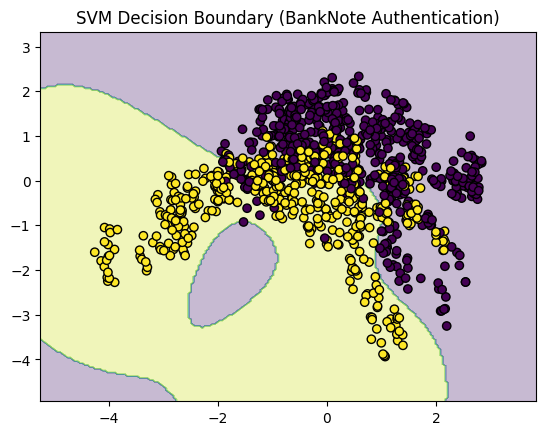

In [8]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

best_model = SVC(kernel='rbf', C=10, probability=True)
best_model.fit(X_pca, Y_train)

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=Y_train, edgecolor='k')
plt.title("SVM Decision Boundary (BankNote Authentication)")
plt.show()

**Support Vectors**

In [9]:
print("Number of Support Vectors:", best_model.n_support_)

Number of Support Vectors: [214 211]


**Model Evaluation**

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

Accuracy: 0.9888888888888889

Confusion Matrix:
 [[145   3]
 [  0 122]]


**Conclusion**

The Support Vector Machine classifier was implemented on the BankNote Authentication dataset and evaluated using different kernels. After training and comparison, the model achieved good classification performance with accurate separation of authentic and non-authentic notes. The results show that SVM effectively handles classification tasks by maximizing the margin and selecting optimal support vectors.
